In [1]:
# =====================================================================
# CELL 1: ENVIRONMENT & MODEL SETUP (Dream 7B)
# =====================================================================
!pip uninstall -y torchvision -q
!pip install transformers==4.46.2 accelerate safetensors sentencepiece einops datasets scikit-learn -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# 1. Load Dream 7B Diffusion Model
model_name = "Dream-org/Dream-v0-Instruct-7B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.padding_side != 'left':
    tokenizer.padding_side = 'left'

# Use bfloat16 to fit in memory (Colab L4 or Kaggle T4x2)
model = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="balanced",
    trust_remote_code=True
).eval()
print("Dream-7B loaded.")

# 2. Load Semantic Embedder for TVS calculation
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("SentenceTransformer loaded.")

# Global Configuration
NUM_DIFFUSION_STEPS = 50
TEMPERATURE = 1.0
NUM_SEEDS = 5
SEEDS = list(range(NUM_SEEDS))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 104.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.27 requires torchvision, which is not installed.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenization_dream.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Dream-org/Dream-v0-Instruct-7B:
- tokenization_dream.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded.


In [2]:
import re
from sklearn.metrics.pairwise import cosine_similarity

# ---> 1. HELPER FUNCTIONS <---
def build_prompt(question, context=None):
    user_content = f"Context:\n{context}\n\nQuestion:\n{question}" if context else question
    messages = [
        {"role": "system", "content": "You are a helpful and knowledgeable AI assistant."},
        {"role": "user", "content": user_content}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def semantic_variance_isolated(outputs, base_sentence):
    isolated_entities = []
    for text in outputs:
        raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
        clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
        isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

    embeddings = embedder.encode(isolated_entities)
    dist = 1 - cosine_similarity(embeddings)
    i, j = np.triu_indices(len(outputs), k=1)
    return np.clip(dist[i, j].mean(), 0, None)

def extract_final_entity(text, base_sentence):
    if base_sentence.lower() in text.lower():
        raw_answer = text.lower().split(base_sentence.lower())[-1]
    else:
        raw_answer = text
    return re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()

# ---> 2. DREAM 7B BATCHED TRAJECTORY GENERATOR (Replaces Cell 3) <---
def generate_trajectory_batched(prompt, num_seeds=5):
    """Generates all 5 seed timelines simultaneously using Dream 7B's native diffusion."""
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    inputs = tokenizer([prompt] * num_seeds, return_tensors="pt", padding=True).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.diffusion_generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=32,
            steps=NUM_DIFFUSION_STEPS,
            temperature=TEMPERATURE,
            output_history=True,          # <--- Triggers Dream 7B to return trajectory history
            return_dict_in_generate=True,
            alg="entropy",                # Dream's advanced remasking strategy
            alg_temp=0.0
        )

    all_trajectories = [[] for _ in range(num_seeds)]

    # Unpack intermediate diffusion history
    for step_tensor in output.history:
        step_tokens = step_tensor[:, prompt_len:]
        texts = tokenizer.batch_decode(step_tokens, skip_special_tokens=True)
        for seed_idx, text in enumerate(texts):
            all_trajectories[seed_idx].append(text.strip())

    return all_trajectories

def run_scenario(prompt, base_sentence, num_seeds=5, return_trajectories=False):
    all_trajectories = generate_trajectory_batched(prompt, num_seeds)
    variances = []
    for step in range(NUM_DIFFUSION_STEPS):
        step_outputs = [traj[step] for traj in all_trajectories]
        variances.append(semantic_variance_isolated(step_outputs, base_sentence))
    if return_trajectories:
        return variances, all_trajectories
    return variances

# ---> 3. DREAM 7B BATCHED FILTER GENERATOR (Replaces Cell 5) <---
def check_memorization_batched_2d(prompts, base_sentences, true_answers, num_seeds=5):
    """Evaluates multiple facts simultaneously for the parametric filter."""
    expanded_prompts = [p for p in prompts for _ in range(num_seeds)]
    inputs = tokenizer(expanded_prompts, return_tensors="pt", padding=True).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.diffusion_generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=32,
            steps=NUM_DIFFUSION_STEPS,
            temperature=TEMPERATURE,
            output_history=False,
            return_dict_in_generate=True,
            alg="entropy",
            alg_temp=0.0
        )

    outputs = tokenizer.batch_decode(output.sequences[:, prompt_len:], skip_special_tokens=True)

    results = []
    for i in range(len(prompts)):
        fact_outputs = outputs[i * num_seeds : (i + 1) * num_seeds]
        correct_count = 0
        for text in fact_outputs:
            predicted_entity = extract_final_entity(text, base_sentences[i])
            if true_answers[i] in predicted_entity:
                correct_count += 1
        results.append(correct_count)

    return results

print("Dream 7B Generator functions loaded and ready!")

Dream 7B Generator functions loaded and ready!


In [3]:
# =====================================================================
# CELL 4: INGEST & UNIFY ALL DATASETS
# =====================================================================
from datasets import load_dataset
import random
from collections import defaultdict

random.seed(42)
raw_eval_pool = []
size = 3000

print("1. Loading SciQ...")
sciq_data = list(load_dataset("sciq", split="train"))
random.shuffle(sciq_data)
for row in sciq_data[:size]:
    raw_eval_pool.append({
        "subject": row["support"].split()[0] if row["support"] else "Science Fact",
        "base": row["question"],
        "true": row["correct_answer"],
        "fake": row["distractor1"], # Built-in plausible fake
        "dataset": "sciq"
    })

print("2. Loading CounterFact...")
cf_data = list(load_dataset("NeelNanda/counterfact-tracing", split="train"))
random.shuffle(cf_data)
for row in cf_data[:size]:
    raw_eval_pool.append({
        "subject": row['subject'],
        "base": row['prompt'],
        "true": row['target_true'],
        "fake": row['target_false'], # Built-in fake
        "dataset": "counterfact"
    })

print("3. Loading PopQA...")
popqa_data = list(load_dataset("akariasai/PopQA", split="test"))
# Group true answers by property to generate highly plausible RAG fakes
relation_groups = defaultdict(list)
for row in popqa_data:
    relation_groups[row['prop']].append(str(row['obj']))
valid_relations = {k: list(set(v)) for k, v in relation_groups.items() if len(set(v)) > 5}

random.shuffle(popqa_data)
popqa_count = 0
for row in popqa_data:
    rel = row['prop']
    if rel not in valid_relations: continue
    true_ans = str(row['obj']).strip()
    possible_fakes = [ans for ans in valid_relations[rel] if ans != true_ans]
    if not possible_fakes: continue

    raw_eval_pool.append({
        "subject": str(row['subj']),
        "base": str(row['question']).strip(),
        "true": true_ans,
        "fake": random.choice(possible_fakes),
        "dataset": "popqa"
    })
    popqa_count += 1
    if popqa_count >= size: break

print("4. Generating Synthetic Relational Data...")
# ---> INSERT FULL DICTIONARY HERE <---
raw_knowledge = {
    "Capital": {
        "template": "The capital of {subject} is",
        "facts": {
            "Afghanistan": "Kabul", "Albania": "Tirana", "Algeria": "Algiers", "Andorra": "Andorra la Vella", "Angola": "Luanda", "Argentina": "Buenos Aires", "Armenia": "Yerevan", "Australia": "Canberra", "Austria": "Vienna", "Azerbaijan": "Baku", "Bahamas": "Nassau", "Bahrain": "Manama", "Bangladesh": "Dhaka", "Barbados": "Bridgetown", "Belarus": "Minsk", "Belgium": "Brussels", "Belize": "Belmopan", "Bhutan": "Thimphu", "Bolivia": "Sucre", "Bosnia": "Sarajevo", "Botswana": "Gaborone", "Brazil": "Brasilia", "Brunei": "Bandar Seri Begawan", "Bulgaria": "Sofia", "Burundi": "Gitega", "Cambodia": "Phnom Penh", "Cameroon": "Yaounde", "Canada": "Ottawa", "Chad": "NDjamena", "Chile": "Santiago", "China": "Beijing", "Colombia": "Bogota", "Comoros": "Moroni", "Costa Rica": "San Jose", "Croatia": "Zagreb", "Cuba": "Havana", "Cyprus": "Nicosia", "Czechia": "Prague", "Denmark": "Copenhagen", "Djibouti": "Djibouti", "Ecuador": "Quito", "Egypt": "Cairo", "Eritrea": "Asmara", "Estonia": "Tallinn", "Ethiopia": "Addis Ababa", "Fiji": "Suva", "Finland": "Helsinki", "France": "Paris", "Gabon": "Libreville", "Gambia": "Banjul", "Georgia": "Tbilisi", "Germany": "Berlin", "Ghana": "Accra", "Greece": "Athens", "Grenada": "St. George's", "Guatemala": "Guatemala City", "Guinea": "Conakry", "Guyana": "Georgetown", "Haiti": "Port-au-Prince", "Honduras": "Tegucigalpa", "Hungary": "Budapest", "Iceland": "Reykjavik", "India": "New Delhi", "Indonesia": "Jakarta", "Iran": "Tehran", "Iraq": "Baghdad", "Ireland": "Dublin", "Israel": "Jerusalem", "Italy": "Rome", "Jamaica": "Kingston", "Japan": "Tokyo", "Jordan": "Amman", "Kazakhstan": "Astana", "Kenya": "Nairobi", "Kiribati": "Tarawa", "Kosovo": "Pristina", "Kuwait": "Kuwait City", "Kyrgyzstan": "Bishkek", "Laos": "Vientiane", "Latvia": "Riga", "Lebanon": "Beirut", "Lesotho": "Maseru", "Liberia": "Monrovia", "Libya": "Tripoli", "Liechtenstein": "Vaduz", "Lithuania": "Vilnius", "Luxembourg": "Luxembourg", "Madagascar": "Antananarivo", "Malawi": "Lilongwe", "Malaysia": "Kuala Lumpur", "Maldives": "Male", "Mali": "Bamako", "Malta": "Valletta", "Mauritania": "Nouakchott", "Mauritius": "Port Louis", "Mexico": "Mexico City", "Moldova": "Chisinau", "Monaco": "Monaco", "Mongolia": "Ulaanbaatar", "Montenegro": "Podgorica", "Morocco": "Rabat", "Mozambique": "Maputo", "Myanmar": "Naypyidaw", "Namibia": "Windhoek", "Nauru": "Yaren", "Nepal": "Kathmandu", "Netherlands": "Amsterdam", "New Zealand": "Wellington", "Nicaragua": "Managua", "Niger": "Niamey", "Nigeria": "Abuja", "North Korea": "Pyongyang", "Norway": "Oslo", "Oman": "Muscat", "Pakistan": "Islamabad", "Palau": "Ngerulmud", "Panama": "Panama City", "Paraguay": "Asuncion", "Peru": "Lima", "Philippines": "Manila", "Poland": "Warsaw", "Portugal": "Lisbon", "Qatar": "Doha", "Romania": "Bucharest", "Russia": "Moscow", "Rwanda": "Kigali", "Samoa": "Apia", "San Marino": "San Marino", "Saudi Arabia": "Riyadh", "Senegal": "Dakar", "Serbia": "Belgrade", "Seychelles": "Victoria", "Sierra Leone": "Freetown", "Singapore": "Singapore", "Slovakia": "Bratislava", "Slovenia": "Ljubljana", "Somalia": "Mogadishu", "South Africa": "Pretoria", "South Korea": "Seoul", "South Sudan": "Juba", "Spain": "Madrid", "Sri Lanka": "Colombo", "Sudan": "Khartoum", "Suriname": "Paramaribo", "Sweden": "Stockholm", "Switzerland": "Bern", "Syria": "Damascus", "Taiwan": "Taipei"
        }
    },
    "US_States": {
        "template": "The capital of the US state {subject} is",
        "facts": {
            "Alabama": "Montgomery", "Alaska": "Juneau", "Arizona": "Phoenix", "Arkansas": "Little Rock", "California": "Sacramento", "Colorado": "Denver", "Connecticut": "Hartford", "Delaware": "Dover", "Florida": "Tallahassee", "Georgia": "Atlanta", "Hawaii": "Honolulu", "Idaho": "Boise", "Illinois": "Springfield", "Indiana": "Indianapolis", "Iowa": "Des Moines", "Kansas": "Topeka", "Kentucky": "Frankfort", "Louisiana": "Baton Rouge", "Maine": "Augusta", "Maryland": "Annapolis", "Massachusetts": "Boston", "Michigan": "Lansing", "Minnesota": "St. Paul", "Mississippi": "Jackson", "Missouri": "Jefferson City", "Montana": "Helena", "Nebraska": "Lincoln", "Nevada": "Carson City", "New Hampshire": "Concord", "New Jersey": "Trenton", "New Mexico": "Santa Fe", "New York": "Albany", "North Carolina": "Raleigh", "North Dakota": "Bismarck", "Ohio": "Columbus", "Oklahoma": "Oklahoma City", "Oregon": "Salem", "Pennsylvania": "Harrisburg", "Rhode Island": "Providence", "South Carolina": "Columbia", "South Dakota": "Pierre", "Tennessee": "Nashville", "Texas": "Austin", "Utah": "Salt Lake City", "Vermont": "Montpelier", "Virginia": "Richmond", "Washington": "Olympia", "West Virginia": "Charleston", "Wisconsin": "Madison", "Wyoming": "Cheyenne"
        }
    },
    "Elements": {
        "template": "The chemical symbol for {subject} is",
        "facts": {
            "Hydrogen": "H", "Helium": "He", "Lithium": "Li", "Beryllium": "Be", "Boron": "B", "Carbon": "C", "Nitrogen": "N", "Oxygen": "O", "Fluorine": "F", "Neon": "Ne", "Sodium": "Na", "Magnesium": "Mg", "Aluminum": "Al", "Silicon": "Si", "Phosphorus": "P", "Sulfur": "S", "Chlorine": "Cl", "Argon": "Ar", "Potassium": "K", "Calcium": "Ca", "Scandium": "Sc", "Titanium": "Ti", "Vanadium": "V", "Chromium": "Cr", "Manganese": "Mn", "Iron": "Fe", "Cobalt": "Co", "Nickel": "Ni", "Copper": "Cu", "Zinc": "Zn", "Gallium": "Ga", "Germanium": "Ge", "Arsenic": "As", "Selenium": "Se", "Bromine": "Br", "Krypton": "Kr", "Rubidium": "Rb", "Strontium": "Sr", "Yttrium": "Y", "Zirconium": "Zr", "Niobium": "Nb", "Molybdenum": "Mo", "Technetium": "Tc", "Ruthenium": "Ru", "Rhodium": "Rh", "Palladium": "Pd", "Silver": "Ag", "Cadmium": "Cd", "Indium": "In", "Tin": "Sn", "Antimony": "Sb", "Tellurium": "Te", "Iodine": "I", "Xenon": "Xe", "Cesium": "Cs", "Barium": "Ba", "Lanthanum": "La", "Cerium": "Ce", "Praseodymium": "Pr", "Neodymium": "Nd", "Promethium": "Pm", "Samarium": "Sm", "Europium": "Eu", "Gadolinium": "Gd", "Terbium": "Tb", "Dysprosium": "Dy", "Holmium": "Ho", "Erbium": "Er", "Thulium": "Tm", "Ytterbium": "Yb", "Lutetium": "Lu", "Hafnium": "Hf", "Tantalum": "Ta", "Tungsten": "W", "Rhenium": "Re", "Osmium": "Os", "Iridium": "Ir", "Platinum": "Pt", "Gold": "Au", "Mercury": "Hg", "Thallium": "Tl", "Lead": "Pb", "Bismuth": "Bi", "Polonium": "Po", "Astatine": "At", "Radon": "Rn", "Francium": "Fr", "Radium": "Ra", "Actinium": "Ac", "Thorium": "Th", "Protactinium": "Pa", "Uranium": "U", "Neptunium": "Np", "Plutonium": "Pu", "Americium": "Am", "Curium": "Cm", "Berkelium": "Bk", "Californium": "Cf", "Einsteinium": "Es"
        }
    },
    "Authors": {
        "template": "The book {subject} was written by",
        "facts": {
            "1984": "George Orwell", "Hamlet": "William Shakespeare", "Pride and Prejudice": "Jane Austen", "The Great Gatsby": "F. Scott Fitzgerald", "Moby-Dick": "Herman Melville", "To Kill a Mockingbird": "Harper Lee", "Frankenstein": "Mary Shelley", "Dracula": "Bram Stoker", "The Hobbit": "J.R.R. Tolkien", "Harry Potter": "J.K. Rowling", "Jane Eyre": "Charlotte Bronte", "Wuthering Heights": "Emily Bronte", "The Odyssey": "Homer", "The Iliad": "Homer", "Crime and Punishment": "Fyodor Dostoevsky", "War and Peace": "Leo Tolstoy", "Anna Karenina": "Leo Tolstoy", "The Catcher in the Rye": "J.D. Salinger", "The Lord of the Rings": "J.R.R. Tolkien", "Fahrenheit 451": "Ray Bradbury", "Brave New World": "Aldous Huxley", "Animal Farm": "George Orwell", "The Grapes of Wrath": "John Steinbeck", "Of Mice and Men": "John Steinbeck", "The Scarlet Letter": "Nathaniel Hawthorne", "The Picture of Dorian Gray": "Oscar Wilde", "A Tale of Two Cities": "Charles Dickens", "Great Expectations": "Charles Dickens", "Oliver Twist": "Charles Dickens", "Les Miserables": "Victor Hugo", "The Hunchback of Notre-Dame": "Victor Hugo", "Don Quixote": "Miguel de Cervantes", "One Hundred Years of Solitude": "Gabriel Garcia Marquez", "Love in the Time of Cholera": "Gabriel Garcia Marquez", "The Alchemist": "Paulo Coelho", "The Kite Runner": "Khaled Hosseini", "A Thousand Splendid Suns": "Khaled Hosseini", "Life of Pi": "Yann Martel", "The Book Thief": "Markus Zusak", "Slaughterhouse-Five": "Kurt Vonnegut", "Catch-22": "Joseph Heller", "The Handmaid's Tale": "Margaret Atwood", "Beloved": "Toni Morrison", "The Color Purple": "Alice Walker", "Invisible Man": "Ralph Ellison", "Native Son": "Richard Wright", "The Bell Jar": "Sylvia Plath", "The Old Man and the Sea": "Ernest Hemingway", "A Farewell to Arms": "Ernest Hemingway", "For Whom the Bell Tolls": "Ernest Hemingway", "The Sun Also Rises": "Ernest Hemingway", "Ulysses": "James Joyce", "Dubliners": "James Joyce", "A Portrait of the Artist as a Young Man": "James Joyce", "The Metamorphosis": "Franz Kafka", "The Trial": "Franz Kafka", "Madame Bovary": "Gustave Flaubert", "In Search of Lost Time": "Marcel Proust", "The Stranger": "Albert Camus", "The Plague": "Albert Camus", "The Divine Comedy": "Dante Alighieri", "The Canterbury Tales": "Geoffrey Chaucer", "Paradise Lost": "John Milton", "Gulliver's Travels": "Jonathan Swift", "Robinson Crusoe": "Daniel Defoe", "Treasure Island": "Robert Louis Stevenson", "Dr. Jekyll and Mr. Hyde": "Robert Louis Stevenson", "Alice's Adventures in Wonderland": "Lewis Carroll", "Through the Looking-Glass": "Lewis Carroll", "The Adventures of Tom Sawyer": "Mark Twain", "Adventures of Huckleberry Finn": "Mark Twain", "Little Women": "Louisa May Alcott", "Anne of Green Gables": "L.M. Montgomery", "The Secret Garden": "Frances Hodgson Burnett", "A Little Princess": "Frances Hodgson Burnett", "The Wind in the Willows": "Kenneth Grahame", "Peter Pan": "J.M. Barrie", "Winnie-the-Pooh": "A.A. Milne", "Charlotte's Web": "E.B. White", "Stuart Little": "E.B. White", "The Chronicles of Narnia": "C.S. Lewis", "The Lion, the Witch and the Wardrobe": "C.S. Lewis", "Charlie and the Chocolate Factory": "Roald Dahl", "Matilda": "Roald Dahl", "The BFG": "Roald Dahl", "James and the Giant Peach": "Roald Dahl", "The Witches": "Roald Dahl", "The Tale of Peter Rabbit": "Beatrix Potter", "Where the Wild Things Are": "Maurice Sendak", "The Giving Tree": "Shel Silverstein", "Goodnight Moon": "Margaret Wise Brown", "The Very Hungry Caterpillar": "Eric Carle", "Green Eggs and Ham": "Dr. Seuss", "The Cat in the Hat": "Dr. Seuss", "How the Grinch Stole Christmas": "Dr. Seuss", "The Lorax": "Dr. Seuss", "Oh, the Places You'll Go": "Dr. Seuss", "Horton Hears a Who": "Dr. Seuss", "The Sneetches": "Dr. Seuss", "Fox in Socks": "Dr. Seuss", "Hop on Pop": "Dr. Seuss"
        }
    },
    "Inventors": {
        "template": "The invention of the {subject} is primarily attributed to",
        "facts": {
            "Telephone": "Alexander Graham Bell", "Light bulb": "Thomas Edison", "Airplane": "Wright Brothers", "Printing press": "Johannes Gutenberg", "World Wide Web": "Tim Berners-Lee", "Penicillin": "Alexander Fleming", "Cotton gin": "Eli Whitney", "Telegraph": "Samuel Morse", "Phonograph": "Thomas Edison", "Steam engine": "James Watt", "Battery": "Alessandro Volta", "Polio vaccine": "Jonas Salk", "Dynamite": "Alfred Nobel", "Barometer": "Evangelista Torricelli", "Thermometer": "Daniel Gabriel Fahrenheit", "Bifocals": "Benjamin Franklin", "Lightning rod": "Benjamin Franklin", "Stethoscope": "Rene Laennec", "Microscope": "Antonie van Leeuwenhoek", "Telescope": "Galileo Galilei", "Pendulum clock": "Christiaan Huygens", "Vaccine": "Edward Jenner", "Pasteurization": "Louis Pasteur", "Radio": "Guglielmo Marconi", "Television": "John Logie Baird", "Diesel engine": "Rudolf Diesel", "Jet engine": "Frank Whittle", "Helicopter": "Igor Sikorsky", "Hovercraft": "Christopher Cockerell", "Submarine": "Cornelis Drebbel", "Machine gun": "Hiram Maxim", "Revolver": "Samuel Colt", "Elevator": "Elisha Otis", "Air conditioning": "Willis Carrier", "Refrigeration": "Jacob Perkins", "Microwave oven": "Percy Spencer", "X-ray": "Wilhelm Rontgen", "Radar": "Robert Watson-Watt", "Laser": "Theodore Maiman", "Transistor": "William Shockley", "Integrated circuit": "Jack Kilby", "Microprocessor": "Marcian Hoff", "Computer mouse": "Douglas Engelbart", "Floppy disk": "Alan Shugart", "Compact disc": "James Russell", "LED": "Nick Holonyak", "Fiber optics": "Charles Kao", "Kevlar": "Stephanie Kwolek", "Velcro": "George de Mestral", "Post-it note": "Spencer Silver", "Safety pin": "Walter Hunt", "Paper clip": "Johan Vaaler", "Zipper": "Whitcomb Judson", "Ballpoint pen": "Laszlo Biro", "Typewriter": "Christopher Latham Sholes", "Sewing machine": "Elias Howe", "Dishwasher": "Josephine Cochrane", "Vacuum cleaner": "Hubert Cecil Booth", "Washing machine": "Alva J. Fisher", "Toaster": "Albert Marsh", "Electric iron": "Henry W. Seely", "Hair dryer": "Alexander F. Godefroy", "Electric razor": "Jacob Schick", "Safety razor": "King C. Gillette", "Matches": "John Walker", "Toothbrush": "William Addis", "Band-Aid": "Earle Dickson", "Q-tips": "Leo Gerstenzang", "Disposable diaper": "Marion Donovan", "Tampon": "Earle Haas", "Contact lenses": "Adolf Gaston Eugen Fick", "Pacemaker": "Wilson Greatbatch", "Defibrillator": "William Kouwenhoven", "MRI": "Raymond Damadian", "CT scanner": "Godfrey Hounsfield", "Ultrasound": "Ian Donald", "Anesthesia": "William T.G. Morton", "Blood bank": "Charles Drew", "Insulin": "Frederick Banting", "Aspirin": "Felix Hoffmann", "Birth control pill": "Gregory Pincus", "DNA structure": "Watson and Crick", "Periodic table": "Dmitri Mendeleev", "Theory of relativity": "Albert Einstein", "Quantum mechanics": "Max Planck", "Evolution by natural selection": "Charles Darwin", "Laws of motion": "Isaac Newton", "Calculus": "Isaac Newton", "Geometry": "Euclid", "Algebra": "Al-Khwarizmi", "Heliocentrism": "Nicolaus Copernicus", "Radioactivity": "Henri Becquerel", "Electron": "J.J. Thomson", "Proton": "Ernest Rutherford", "Neutron": "James Chadwick", "Atomic bomb": "J. Robert Oppenheimer", "Hydrogen bomb": "Edward Teller", "Nuclear reactor": "Enrico Fermi", "Space shuttle": "George Mueller", "Saturn V rocket": "Wernher von Braun", "International Space Station": "NASA"
        }
    }
}

temp_synthetic_pool = []
for category, data in raw_knowledge.items():
    template, facts = data["template"], data["facts"]
    all_answers = list(facts.values())

    for subject, true_ans in facts.items():
        possible_fakes = [ans for ans in all_answers if ans != true_ans]
        temp_synthetic_pool.append({
            "subject": subject,
            "base": template.format(subject=subject),
            "true": true_ans,
            "fake": random.choice(possible_fakes),
            "dataset": "synthetic"
        })

# Shuffle the synthetic facts and grab exactly `size` elements
random.shuffle(temp_synthetic_pool)
raw_eval_pool.extend(temp_synthetic_pool[:size])

random.shuffle(raw_eval_pool)
print(f"\n✅ ALL DATASETS UNIFIED. Total Candidates: {len(raw_eval_pool)}")

1. Loading SciQ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/339k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


test.tsv: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/14267 [00:00<?, ? examples/s]

4. Generating Synthetic Relational Data...

✅ ALL DATASETS UNIFIED. Total Candidates: 9499


In [4]:
from google.colab import drive

# Mount your Google Drive at /content/drive
drive.mount('/content/drive')

print("\nDrive mounted! Your files can now be saved to: /content/drive/MyDrive/")

Mounted at /content/drive

Drive mounted! Your files can now be saved to: /content/drive/MyDrive/


In [ ]:
# =====================================================================
# CELL 5: PARAMETRIC MEMORY FILTER (2D BATCHED)
# =====================================================================
import json
import time # <--- Added time module

CHUNK_SIZE = 1

print(f"Starting 2D Batched Parametric Knowledge Filter on {len(raw_eval_pool)} facts...")
print(f"Strict criteria: {NUM_SEEDS-1}/{NUM_SEEDS} seeds must be correct.\n")

verified_eval_facts = []
failed_eval_facts = []

verified_save_path = "/content/drive/MyDrive/dream/verified_master_dataset.json"

# ---> START THE CLOCK <---
start_time = time.time()

for i in range(0, len(raw_eval_pool), CHUNK_SIZE):
    # Slice a chunk of facts from the pool
    chunk = raw_eval_pool[i : i + CHUNK_SIZE]

    prompts = []
    base_sentences = []
    true_answers = []

    # Prep the data for this specific chunk
    for fact in chunk:
        base_sentence = fact["base"]
        base_sentences.append(base_sentence)
        true_answers.append(str(fact["true"]).lower())

        # Format prompt based on dataset type
        if fact["dataset"] in ["sciq", "popqa"]:
            question = f"Answer the following question: {base_sentence}"
        else:
            question = f"Complete the sentence: {base_sentence}"

        prompts.append(build_prompt(question, context=""))

    # Trigger the massive 2D batch generation
    correct_counts = check_memorization_batched_2d(prompts, base_sentences, true_answers, num_seeds=NUM_SEEDS)

    # Process the results for the chunk
    for j, fact in enumerate(chunk):
        correct_count = correct_counts[j]
        current_idx = i + j + 1

        if correct_count >= (NUM_SEEDS - 1):
            print(f"[{current_idx}/{len(raw_eval_pool)}] [PASS] {fact['dataset'].upper():<12} | {fact['subject'][:20]:<20} | {correct_count}/{NUM_SEEDS}")
            verified_eval_facts.append(fact)
        else:
            failed_eval_facts.append(fact)

    # Auto-save checkpointing: Check if we crossed a 100-fact boundary or hit the end
    if (i + CHUNK_SIZE) // 100 > i // 100 or (i + CHUNK_SIZE) >= len(raw_eval_pool):
        with open(verified_save_path, "w") as f:
            json.dump(verified_eval_facts, f, indent=4)
        print(f"   [AUTO-SAVE] Checkpoint reached. Master dataset file updated.")

# ---> STOP THE CLOCK <---
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60

print("\n" + "="*50)
print(f"FILTERING COMPLETE")
print("="*50)
print(f"Verified Dataset : {len(verified_eval_facts)} facts (High Parametric Confidence)")
print(f"Discarded        : {len(failed_eval_facts)} facts")
print(f"Total Time       : {elapsed_minutes:.2f} minutes") # <--- Print the timing

Starting 2D Batched Parametric Knowledge Filter on 9499 facts...
Strict criteria: 4/5 seeds must be correct.

[5/9499] [PASS] SCIQ         | Charge               | 5/5
[6/9499] [PASS] SYNTHETIC    | Iron                 | 5/5
[7/9499] [PASS] SYNTHETIC    | Sulfur               | 5/5
[16/9499] [PASS] POPQA        | Valdemar III of Denm | 5/5
[30/9499] [PASS] SCIQ         | The                  | 5/5
[32/9499] [PASS] SCIQ         | The                  | 4/5
[35/9499] [PASS] SCIQ         | (A)                  | 4/5
[36/9499] [PASS] COUNTERFACT  | Chakrapani           | 4/5
[37/9499] [PASS] SCIQ         | When                 | 4/5
[38/9499] [PASS] SCIQ         | Compared             | 5/5
[41/9499] [PASS] SCIQ         | A                    | 5/5
[50/9499] [PASS] SCIQ         | An                   | 5/5
[52/9499] [PASS] SCIQ         | character            | 5/5
[54/9499] [PASS] SCIQ         | The                  | 4/5
[55/9499] [PASS] SCIQ         | Nonvascular          | 5/5
[62/9499

In [5]:
# =====================================================================
# CELL 6: CROSS-DOMAIN TVS GENERATION (WITH RESUME LOGIC)
# =====================================================================
import time
import os
import json
import numpy as np
# ---> LOAD THE VERIFIED DATASET FROM DISK <---
print("Loading Verified Master Dataset from Google Drive...")
with open("/content/drive/MyDrive/dream/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)
NUM_FACTS = len(verified_eval_facts)
save_path = "/content/drive/MyDrive/dream/tvs_master_variance_arrays_extra.npz"
clean_raw_list, clean_diff_list = [], []
conflict_raw_list, conflict_diff_list = [], []
clean_traj_list, conflict_traj_list = [], []
start_idx = 0
# ---> RESUME LOGIC <---
if os.path.exists(save_path):
    print(f"Found existing save file at {save_path}. Loading previous progress...")
    data = np.load(save_path)

    # Convert numpy arrays back to Python lists so we can continue appending
    clean_raw_list = list(data['clean_raw'])
    clean_diff_list = list(data['clean_diff'])
    clean_traj_list = list(data['clean_traj'])

    conflict_raw_list = list(data['conflict_raw'])
    conflict_diff_list = list(data['conflict_diff'])
    conflict_traj_list = list(data['conflict_traj'])

    # The length of the loaded list gives us our starting index
    start_idx = len(clean_raw_list)
    print(f"Successfully loaded {start_idx} items. Resuming from item {start_idx + 1}...")
else:
    print("No existing save file found. Starting from scratch...")
print(f"Starting TVS trajectory generation...")
start_time = time.time()
# Use range starting from start_idx instead of enumerate
for i in range(start_idx, NUM_FACTS):
    fact = verified_eval_facts[i]
    base_sentence = fact["base"]
    dataset_type = fact["dataset"]

    print(f"[{i+1}/{NUM_FACTS}] Generating TVS: {fact['subject'][:25]:<25} ({dataset_type.upper()})")

    # Prompt constraint logic
    if dataset_type in ["sciq", "popqa"]:
        question = f"Answer strictly with the entity name. Question: {base_sentence}"
    else:
        question = f"Complete the sentence: {base_sentence}"

    # RAG Context injection
    context_clean = f"{base_sentence} {fact['true']}."
    context_conflict = f"{base_sentence} {fact['fake']}."
    prompt_clean = build_prompt(question, context=context_clean)
    prompt_conflict = build_prompt(question, context=context_conflict)

    try:
        # Generate raw 50-timestep variance
        var_clean, traj_clean = run_scenario(prompt_clean, base_sentence, return_trajectories=True)
        var_conflict, traj_conflict = run_scenario(prompt_conflict, base_sentence, return_trajectories=True)

        # Calculate velocity (diff)
        diff_clean = np.diff(var_clean, prepend=var_clean[0])
        diff_conflict = np.diff(var_conflict, prepend=var_conflict[0])

        clean_raw_list.append(var_clean)
        clean_diff_list.append(diff_clean)
        clean_traj_list.append(traj_clean)
        conflict_raw_list.append(var_conflict)
        conflict_diff_list.append(diff_conflict)
        conflict_traj_list.append(traj_conflict)
    except Exception as e:
        print(f"   -> [ERROR] Failed on {fact['subject']}: {e}")

    # Auto-save every 50 facts to prevent progress loss
    if (i + 1) % 50 == 0 or (i + 1) == NUM_FACTS:
        np.savez_compressed(
            save_path,
            clean_raw=np.array(clean_raw_list), clean_diff=np.array(clean_diff_list),
            clean_traj=np.array(clean_traj_list),
            conflict_raw=np.array(conflict_raw_list), conflict_diff=np.array(conflict_diff_list),
            conflict_traj=np.array(conflict_traj_list)
        )
        print(f"   [AUTO-SAVE] Checkpoint reached. Arrays safely dumped to disk.")

elapsed_time = (time.time() - start_time) / 60
print("\n" + "="*50)
print(f"SUCCESS! TVS Dataset securely saved to '{save_path}' (Took {elapsed_time:.1f} mins)")
print(f"Clean Data Shape:    {np.array(clean_raw_list).shape}")
print(f"Conflict Data Shape: {np.array(conflict_raw_list).shape}")
print(f"Clean Traj Shape:    {np.array(clean_traj_list).shape}")
print(f"Conflict Traj Shape: {np.array(conflict_traj_list).shape}")
print("="*50)

Loading Verified Master Dataset from Google Drive...
No existing save file found. Starting from scratch...
Starting TVS trajectory generation...
[1/2370] Generating TVS: Charge                    (SCIQ)
[2/2370] Generating TVS: Iron                      (SYNTHETIC)
[3/2370] Generating TVS: Sulfur                    (SYNTHETIC)
[4/2370] Generating TVS: Valdemar III of Denmark   (POPQA)
[5/2370] Generating TVS: The                       (SCIQ)
[6/2370] Generating TVS: The                       (SCIQ)
[7/2370] Generating TVS: (A)                       (SCIQ)
[8/2370] Generating TVS: Chakrapani                (COUNTERFACT)
[9/2370] Generating TVS: When                      (SCIQ)
[10/2370] Generating TVS: Compared                  (SCIQ)
[11/2370] Generating TVS: A                         (SCIQ)
[12/2370] Generating TVS: An                        (SCIQ)
[13/2370] Generating TVS: character                 (SCIQ)
[14/2370] Generating TVS: The                       (SCIQ)
[15/2370] Generating

In [6]:
# =====================================================================
# CELL 7: DATA PREPARATION (DYNAMIC SEED ABLATION - ULTRA FAST BATCHED)
# =====================================================================
import numpy as np
import torch
import json
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# ---------------------------------------------------------------------
# [!] N=2 SEEDS SETUP (DELTA VARIANCE CHANNEL REMOVED)
NUM_SEEDS_TO_USE = 2
# ---------------------------------------------------------------------

print(f"Loading Trajectories from Google Drive (Evaluating with {NUM_SEEDS_TO_USE} seeds)...")
dataset = np.load("/content/drive/MyDrive/dream/tvs_master_variance_arrays_extra.npz")
clean_traj = dataset['clean_traj']
conflict_traj = dataset['conflict_traj']

print("Loading Verified Master Dataset for base sentences...")
with open("/content/drive/MyDrive/dream/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

NUM_FACTS = clean_traj.shape[0]
clean_raw_k = []
conflict_raw_k = []

print(f"Recalculating Semantic Variance for {NUM_SEEDS_TO_USE} seeds (Optimized Batched Mode!)...")
for i in tqdm(range(NUM_FACTS)):
    base_sentence = verified_eval_facts[i]["base"]

    # [K_Seeds, 50]
    c_traj_k = clean_traj[i, :NUM_SEEDS_TO_USE, :]
    conf_traj_k = conflict_traj[i, :NUM_SEEDS_TO_USE, :]

    K = c_traj_k.shape[0]

    # Transpose to [50, K] so we group seeds for the same timestep adjacent to each other
    # Then flatten to a 1D list of strings
    c_flat = c_traj_k.T.flatten()
    conf_flat = conf_traj_k.T.flatten()

    # Combine Clean and Conflict strings (Total length = 2 * 50 * K)
    all_texts = np.concatenate([c_flat, conf_flat])

    isolated_entities = []
    for text in all_texts:
        raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
        clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
        isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

    # BATCH ENCODE: 1 call per fact instead of 100 calls! Massively faster!
    embeddings = embedder.encode(isolated_entities, batch_size=200, show_progress_bar=False)

    c_vars = []
    conf_vars = []

    # Extract Clean Variances
    for step in range(50):
        start_idx = step * K
        end_idx = start_idx + K
        step_embs = embeddings[start_idx:end_idx]

        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        c_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    # Extract Conflict Variances
    offset = 50 * K
    for step in range(50):
        start_idx = offset + (step * K)
        end_idx = start_idx + K
        step_embs = embeddings[start_idx:end_idx]

        dist = 1 - cosine_similarity(step_embs)
        i_idx, j_idx = np.triu_indices(K, k=1)
        conf_vars.append(np.clip(dist[i_idx, j_idx].mean(), 0, None))

    clean_raw_k.append(c_vars)
    conflict_raw_k.append(conf_vars)

clean_raw = np.array(clean_raw_k)
conflict_raw = np.array(conflict_raw_k)

# Delta TVS (Velocity) generation has been removed as requested for this ablation.
X_list, y_list = [], []
for i in range(NUM_FACTS):
    # Only stacking the raw variance (1 feature channel)
    X_list.append(np.expand_dims(clean_raw[i], axis=0))
    y_list.append(0)
    X_list.append(np.expand_dims(conflict_raw[i], axis=0))
    y_list.append(1)

# Shape configuration: (Batch, Time, Channels) -> (Batch, 50, 1)
X = torch.tensor(np.array(X_list), dtype=torch.float32).permute(0, 2, 1)
y = torch.tensor(y_list, dtype=torch.float32).unsqueeze(1)

# --- STRICT 70/15/15 SPLIT ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("\n" + "="*50)
print(f"DATASET SPLIT COMPLETE (SEEDS = {NUM_SEEDS_TO_USE}, 1 CHANNEL)")
print("="*50)

Loading Trajectories from Google Drive (Evaluating with 2 seeds)...
Loading Verified Master Dataset for base sentences...
Recalculating Semantic Variance for 2 seeds (Optimized Batched Mode!)...


100%|██████████| 2370/2370 [03:30<00:00, 11.28it/s]



DATASET SPLIT COMPLETE (SEEDS = 2, 1 CHANNEL)


Loading Verified Master Dataset from Google Drive...

STARTING LOGISTIC REGRESSION ABLATION (5 RUNS)
  -> Run 1/5 | Test Acc: 63.43% | F1: 60.61% | AUROC: 0.6769
  -> Run 2/5 | Test Acc: 62.59% | F1: 58.95% | AUROC: 0.6785
  -> Run 3/5 | Test Acc: 65.68% | F1: 63.36% | AUROC: 0.6925
  -> Run 4/5 | Test Acc: 64.84% | F1: 63.66% | AUROC: 0.7008
  -> Run 5/5 | Test Acc: 63.01% | F1: 59.22% | AUROC: 0.6994

--- LOGISTIC REGRESSION FINAL RESULTS ---
Overall Accuracy : 63.91% ± 1.17%
Overall Precision: 66.13% ± 0.91%
Overall Recall   : 56.95% ± 3.10%
Overall F1 Score : 61.16% ± 2.00%
Overall AUROC    : 0.6896 ± 0.0101

--- PER-DATASET ACCURACY (Averaged across test sets) ---
COUNTERFACT     | Accuracy: 58.16% ± 5.60%
POPQA           | Accuracy: 59.59% ± 3.94%
SCIQ            | Accuracy: 65.63% ± 1.54%
SYNTHETIC       | Accuracy: 64.82% ± 4.24%


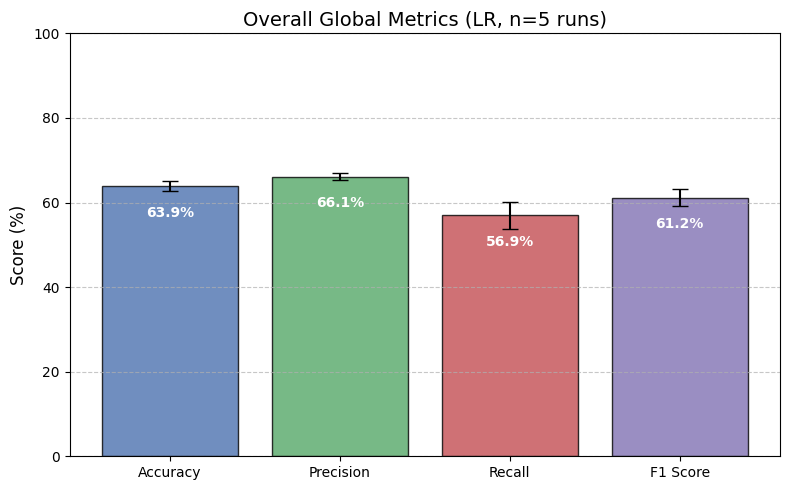

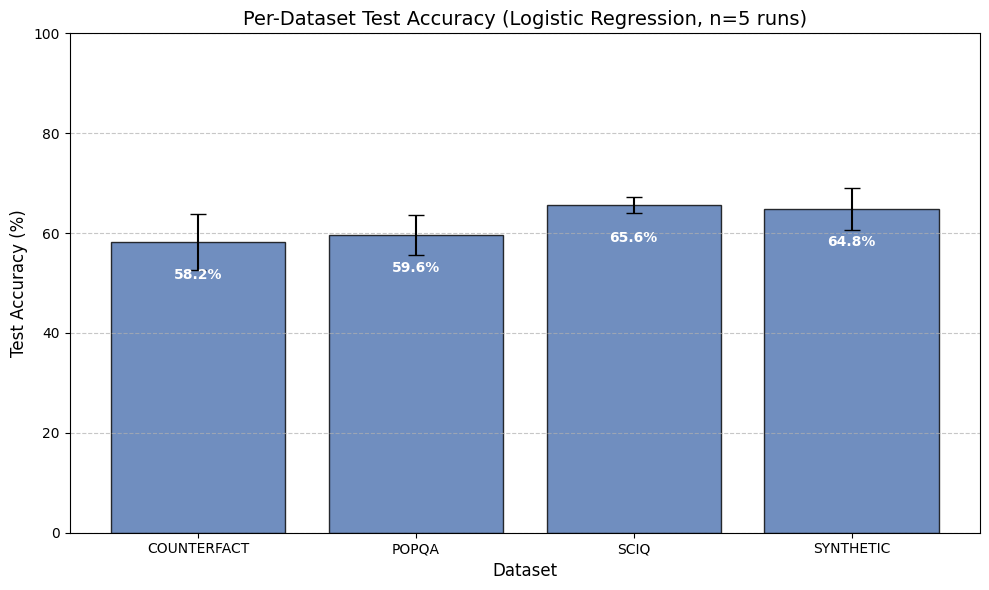

In [7]:
# =====================================================================
# CELL 8: MULTI-RUN LOGISTIC REGRESSION ABLATION & PER-DATASET METRICS
# =====================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import defaultdict

NUM_RUNS = 5

print("Loading Verified Master Dataset from Google Drive...")
with open("/content/drive/MyDrive/dream/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

print(f"\n{'='*70}")
print(f"STARTING LOGISTIC REGRESSION ABLATION ({NUM_RUNS} RUNS)")
print(f"{'='*70}")

# Flatten the entire X dataset upfront for Scikit-Learn
X_flat = X.numpy().reshape(X.shape[0], -1)
y_np = y.numpy().flatten()
indices = np.arange(len(y_np))

overall_acc_list = []
overall_auroc_list = []
overall_prec_list = []
overall_rec_list = []
overall_f1_list = []

ds_acc_history = defaultdict(list)

for run in range(NUM_RUNS):
    print(f"  -> Run {run+1}/{NUM_RUNS}", end="")

    # Split Data AND indices to track dataset origins
    X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
        X_flat, y_np, indices, test_size=0.30, random_state=42+run, stratify=y_np
    )
    # FIXED TYPO HERE: changed y_test, y_test to y_val, y_test
    X_val, X_test, y_val, y_test, idx_val, idx_test = train_test_split(
        X_temp, y_temp, idx_temp, test_size=0.50, random_state=42+run, stratify=y_temp
    )

    # Train Logistic Regression
    lr_model = LogisticRegression(max_iter=2000, random_state=42)
    lr_model.fit(X_train, y_train)

    # Predict on unseen TEST set
    test_probs = lr_model.predict_proba(X_test)[:, 1]
    test_preds = lr_model.predict(X_test)

    # Overall Metrics
    acc = accuracy_score(y_test, test_preds)
    auroc = roc_auc_score(y_test, test_probs)
    prec = precision_score(y_test, test_preds)
    rec = recall_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds)

    overall_acc_list.append(acc * 100)
    overall_auroc_list.append(auroc)
    overall_prec_list.append(prec * 100)
    overall_rec_list.append(rec * 100)
    overall_f1_list.append(f1 * 100)

    print(f" | Test Acc: {acc * 100:.2f}% | F1: {f1 * 100:.2f}% | AUROC: {auroc:.4f}")

    # --- PER-DATASET METRICS (For this specific run) ---
    run_ds_correct = defaultdict(int)
    run_ds_total = defaultdict(int)

    for k in range(len(y_test)):
        true_label = int(y_test[k])
        pred_label = int(test_preds[k])

        # Map back to original fact JSON
        original_fact_index = idx_test[k] // 2
        fact = verified_eval_facts[original_fact_index]
        ds_name = fact.get("dataset", "unknown").upper()

        run_ds_total[ds_name] += 1
        if true_label == pred_label:
            run_ds_correct[ds_name] += 1

    # Calculate dataset accuracy for this run and store it
    for ds_name in run_ds_total.keys():
        run_acc = (run_ds_correct[ds_name] / run_ds_total[ds_name]) * 100
        ds_acc_history[ds_name].append(run_acc)

# =====================================================================
# PRINT REPORTS
# =====================================================================
print("\n" + "="*55)
print("--- LOGISTIC REGRESSION FINAL RESULTS ---")
print("="*55)
print(f"Overall Accuracy : {np.mean(overall_acc_list):.2f}% ± {np.std(overall_acc_list):.2f}%")
print(f"Overall Precision: {np.mean(overall_prec_list):.2f}% ± {np.std(overall_prec_list):.2f}%")
print(f"Overall Recall   : {np.mean(overall_rec_list):.2f}% ± {np.std(overall_rec_list):.2f}%")
print(f"Overall F1 Score : {np.mean(overall_f1_list):.2f}% ± {np.std(overall_f1_list):.2f}%")
print(f"Overall AUROC    : {np.mean(overall_auroc_list):.4f} ± {np.std(overall_auroc_list):.4f}")

print("\n" + "="*55)
print("--- PER-DATASET ACCURACY (Averaged across test sets) ---")
print("="*55)

mean_ds_accs = {}
std_ds_accs = {}

for ds in sorted(ds_acc_history.keys()):
    mean_val = np.mean(ds_acc_history[ds])
    std_val = np.std(ds_acc_history[ds])
    mean_ds_accs[ds] = mean_val
    std_ds_accs[ds] = std_val
    print(f"{ds:<15} | Accuracy: {mean_val:>5.2f}% ± {std_val:>4.2f}%")
print("="*55)

# =====================================================================
# GENERATE GRAPHS WITH ERROR BARS
# =====================================================================

# GRAPH 1: OVERALL METRICS
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_means = [np.mean(overall_acc_list), np.mean(overall_prec_list), np.mean(overall_rec_list), np.mean(overall_f1_list)]
metrics_stds = [np.std(overall_acc_list), np.std(overall_prec_list), np.std(overall_rec_list), np.std(overall_f1_list)]

plt.figure(figsize=(8, 5))
bars1 = plt.bar(metrics_names, metrics_means, yerr=metrics_stds, capsize=6, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'], edgecolor='black', alpha=0.8)

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 8, f'{yval:.1f}%', ha='center', va='bottom', color='white', fontweight='bold')

plt.title(f"Overall Global Metrics (LR, n={NUM_RUNS} runs)", fontsize=14)
plt.ylabel("Score (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# GRAPH 2: PER-DATASET ACCURACY
datasets = list(mean_ds_accs.keys())
means = [mean_ds_accs[ds] for ds in datasets]
stds = [std_ds_accs[ds] for ds in datasets]

plt.figure(figsize=(10, 6))
bars2 = plt.bar(datasets, means, yerr=stds, capsize=6, color='#4C72B0', edgecolor='black', alpha=0.8)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval - 8, f'{yval:.1f}%', ha='center', va='bottom', color='white', fontweight='bold')

plt.title(f"Per-Dataset Test Accuracy (Logistic Regression, n={NUM_RUNS} runs)", fontsize=14)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

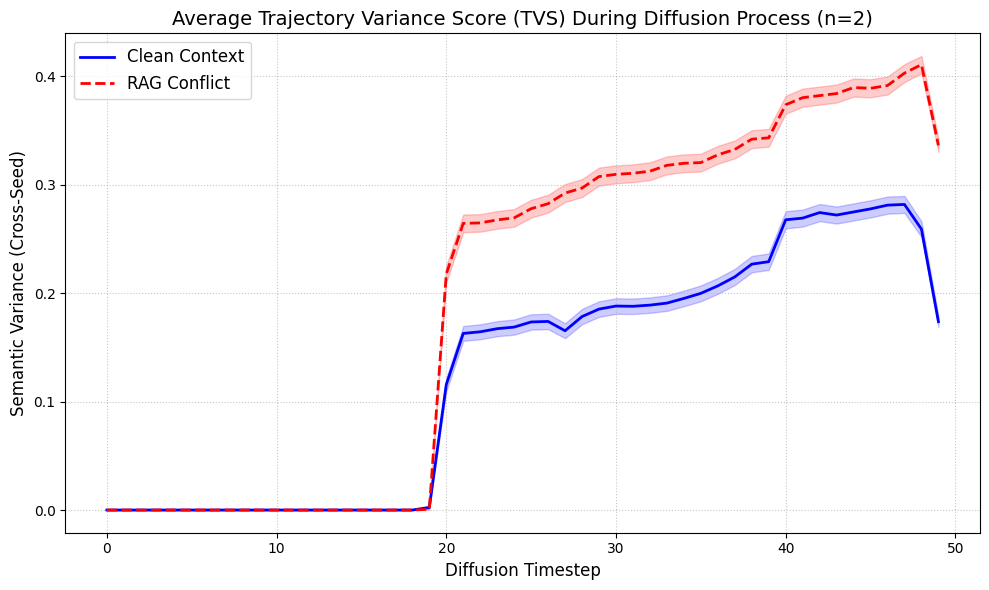

Graph saved to Google Drive as '/content/drive/MyDrive/dream/tvs_conflict_graph.png'


In [8]:
# =====================================================================
# CELL 10: TVS VISUALIZATION (FIGURE GENERATION)
# =====================================================================
import matplotlib.pyplot as plt
import numpy as np

# Calculate the mean variance across all samples at each timestep
mean_clean_tvs = np.mean(clean_raw, axis=0)
mean_conflict_tvs = np.mean(conflict_raw, axis=0)

# Optional: Calculate standard deviation for confidence intervals
std_clean_tvs = np.std(clean_raw, axis=0) / np.sqrt(NUM_FACTS)
std_conflict_tvs = np.std(conflict_raw, axis=0) / np.sqrt(NUM_FACTS)

timesteps = np.arange(clean_raw.shape[1])

plt.figure(figsize=(10, 6))
plt.plot(timesteps, mean_clean_tvs, label='Clean Context', color='blue', linewidth=2)
plt.fill_between(timesteps, mean_clean_tvs - std_clean_tvs, mean_clean_tvs + std_clean_tvs, color='blue', alpha=0.2)

plt.plot(timesteps, mean_conflict_tvs, label='RAG Conflict', color='red', linewidth=2, linestyle='--')
plt.fill_between(timesteps, mean_conflict_tvs - std_conflict_tvs, mean_conflict_tvs + std_conflict_tvs, color='red', alpha=0.2)

plt.title(f'Average Trajectory Variance Score (TVS) During Diffusion Process (n={NUM_SEEDS_TO_USE})', fontsize=14)
plt.xlabel('Diffusion Timestep', fontsize=12)
plt.ylabel('Semantic Variance (Cross-Seed)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Save the figure directly for the manuscript to Google Drive
plt.savefig('/content/drive/MyDrive/dream/tvs_conflict_graph.png', dpi=300)
plt.show()

print("Graph saved to Google Drive as '/content/drive/MyDrive/dream/tvs_conflict_graph.png'")